# Stochastic Expectation-Maximization

In this notebook, I'll describe and demonstrate an early version of *stochastic expectation maximization* (SEM), a technique that I learned about primarily from [this paper](https://proceedings.neurips.cc/paper_files/paper/2018/hash/aba22f748b1a6dff75bda4fd1ee9fe07-Abstract.html). This framework applies when the joint distribution between latent and observed variables is in an exponential family, which is indeed true in our case. 

### SEM

I implemented the calculation of the basic SEM update. This update consists in performing an EM-like parameter update using a *single* edge and modifying the current estimate accordingly. Suppose that we have a current estimate $\hat{\theta}^{(t)}$ at time $t$, and that in step $t+1$ we get an update $\theta'$. Then, the basic new estimate in the SEM framework is 

$$
\hat{\theta}^{(t+1)}  = (1-\rho^{(t)})\hat{\theta}^{(t)} + \rho^{(t)}\theta'. 
$$

We can think of $\rho^{(t)}$ as a learning rate that tunes how quickly the parameter update occurs. As in other optimization frameworks, it is possible to choose $\rho^{(t)}$ to decrease over time. In the cited paper above, the authors instead take a different approach in which they modify the update in order to make it unnecessary to tune the learning rate. 

### In Our Work

So far, we have implemented SEM and recently implemented minibatch SEM in which the vector of sufficient statistics used to compute the updates is computed from a small set of edges, rather than from an individual one. 

In [1]:
%load_ext autoreload
%autoreload 2

import importlib
import scipy.special as ss
import functools
import xgi
from collections import Counter
from statsmodels.tsa.stattools import adfuller
from arch.unitroot import DFGLS

m = importlib.import_module(".model", "src")
#mn = importlib.import_module(".model_new", "src")
sem = importlib.import_module(".sem", "src") 
#semn = importlib.import_module(".sem_new", "src") 
em = importlib.import_module(".em", "src")
ll = importlib.import_module(".likelihoods", "src")
from matplotlib import pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')

def expectation(x):
    
    to_sum = [(i)*j for i,j in enumerate(x)]
      
    return sum(to_sum)



def KL(a, b):
    a = np.array(a)
    b = np.array(b)

    return np.sum(np.where(a != 0, a * np.log(a / b), 0))


C:\Users\hexie\.conda\envs\Hgraph\lib\site-packages\xgi\__init__.py:1: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources
C:\Users\hexie\.conda\envs\Hgraph\lib\site-packages\xgi\utils\utilities.py:9: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Here's a simple example of our implementation working well. 

In [2]:
# generate some sample data

eta   = 0.3   # node retention in edges
beta  = [0.91, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01]
gamma = [0.4, 0.25, 0.15, 0.05, 0.05, 0.02, 0.02, 0.02, 0.02, 0.02]   # poisson number of nodes from graph


In [3]:
# track the parameter estimates over time

def experiment(parameters, steps, ax = None, batch_size = 1, verbose = False):
    
    eta = parameters["eta"]
    beta = parameters["beta"]
    gamma = parameters["gamma"]
    
    
    timesteps = int(1e4)

    H = m.GrowingHypergraph()
    H.add_edge((0, 1))
    H.add_edge((2, 3))
    
    for _ in range(timesteps):
        e_ = H.sample_edge(eta, gamma, beta, True)
    #added.append(num)
    
    print(f"This hypergraph has {len(H.edge_size_sequence())} edges and {len(H.degree_sequence())} nodes.")

    
    init_pars = {"eta"   : 0.5, 
             "beta"  : [1/10]*10, 
             "gamma" : [1/20]*20}
    
    if not ax: 
        fig, ax = plt.subplots(1, 1)
        
    EM = sem.SEM(H, 
             ll.guaranteed_edge_sample_likelihood,
             ll.nodes_from_hypergraph_likelihood,
             ll.novel_nodes_likelihood,
             pars = init_pars.copy(), 
             memoize = True)
    
    epochs = int(steps / batch_size)
    
    ETA   = np.zeros(epochs)
    BETA  = []
    GAMMA = []

    # main loop
    for i in range(epochs):

        if i % max(int(epochs/20), 1) == 0 and verbose:
            print("--------")
            print(f"Completed epoch {i}")
            print(EM.pars)
            
        EM.SEM_step(0.002*batch_size, batch_size = batch_size) # both the stochastic E and the M steps are in here
        ETA[i] = EM.pars["eta"]
        BETA.append(expectation(EM.pars["beta"]))
        GAMMA.append(expectation(EM.pars["gamma"]))

    # how'd we do?     
    T = np.arange(epochs)
    ax.plot(T, ETA,   label = r"$\hat{\eta} = $" + str(eta), color = "blue")
    ax.plot(T, BETA,  label = r"$\hat{\beta}$" + str(round(expectation(beta),2)), color = "black")
    ax.plot(T, GAMMA, label = r"$\hat{\gamma}$" + str(round(expectation(gamma),2)), color = "grey")

    ax.plot(T, np.ones((epochs,))*eta, color = "cornflowerblue", linestyle = "dashed")
    ax.plot(T, np.ones((epochs,))*expectation(beta), color = "palevioletred", linestyle = "dashed")
    ax.plot(T, np.ones((epochs,))*expectation(gamma), color = "olivedrab", linestyle = "dashed")
    
    ax.set(xlabel = "epoch", ylabel = "parameter estimate")
    ax.legend()
    
    return ETA, BETA, GAMMA

In [4]:
def experiment_KL(parameters, steps,  beta_mu, gamma_mu, ax = None, batch_size = 1, verbose = False, legend_on = True):
    
    eta = parameters["eta"]
    beta = parameters["beta"]
    gamma = parameters["gamma"]
    
    
    timesteps = int(1e4)

    H = m.GrowingHypergraph()
    H.add_edge((0, 1))
    H.add_edge((2, 3))
    
    for _ in range(timesteps):
        e_ = H.sample_edge(eta, gamma, beta, True)
    #added.append(num)
    
    print(f"This hypergraph has {len(H.edge_size_sequence())} edges and {len(H.degree_sequence())} nodes.")

    
    init_pars = {"eta"   : 0.5, 
             "beta"  : [1/10]*10, 
             "gamma" : [1/10]*10}
    
    if not ax: 
        fig, ax = plt.subplots(1, 1)
        
    EM = sem.SEM(H, 
             ll.guaranteed_edge_sample_likelihood,
             ll.nodes_from_hypergraph_likelihood,
             ll.novel_nodes_likelihood,
             pars = init_pars.copy(), 
             memoize = True)
    
    epochs = int(steps / batch_size)
    
    ETA   = []
    BETA  = []
    GAMMA = []

    # main loop
    for i in range(epochs):

        if i % max(int(epochs/20), 1) == 0 and verbose:
            print("--------")
            print(f"Completed epoch {i}")
            print(EM.pars)
            
        EM.SEM_step(0.002*batch_size, batch_size = batch_size) # both the stochastic E and the M steps are in here
        ETA.append(abs(EM.pars["eta"] - eta))
        BETA.append(KL(EM.pars["beta"], beta))
        GAMMA.append(KL(EM.pars["gamma"], gamma))

    # how'd we do?     
    T = np.arange(epochs)
    ax.plot(T, ETA,   label = r"$|\hat{\eta} - \eta|$ for $\eta$ = " + str(eta) , color = "cornflowerblue")
    ax.plot(T, BETA,  label = r"$KL(\hat{\beta}, \beta)$ for $\mu_{\beta}$ = " + str(beta_mu), color = "sandybrown")
    ax.plot(T, GAMMA, label = r"$KL(\hat{\gamma}, \gamma)$ for $\mu_{\gamma}$ = " + str(gamma_mu), color = "olivedrab")

#     ax.plot(T, np.ones((epochs,))*eta, color = "blue", linestyle = "dashed")
#     ax.plot(T, np.ones((epochs,))*expectation(beta), color = "black", linestyle = "dashed")
#     ax.plot(T, np.ones((epochs,))*expectation(gamma), color = "grey", linestyle = "dashed")
    
    ax.set_yscale('log')
    ax.set(xlabel = "Algorithmic timestep")
    if legend_on:
        ax.set(ylabel = "Error in parameter estimate")
    ax.legend()
    
    return ETA, BETA, GAMMA

In [5]:
def experiment_KL_ADF(parameters, steps, beta_mu, gamma_mu, ax = None, batch_size = 1, verbose = False, legend_on = True):
    
    # KL convergence and Augmented Dickey-Fuller test for convergence of time series data. 
    
    eta = parameters["eta"]
    beta = parameters["beta"]
    gamma = parameters["gamma"]
    
    
    timesteps = int(1e4)

    H = m.GrowingHypergraph()
    H.add_edge((0, 1))
    H.add_edge((2, 3))
    
    for _ in range(timesteps):
        e_ = H.sample_edge(eta, gamma, beta, True)
    #added.append(num)
    
    print(f"This hypergraph has {len(H.edge_size_sequence())} edges and {len(H.degree_sequence())} nodes.")

    
    init_pars = {"eta"   : 0.5, 
             "beta"  : [1/10]*10, 
             "gamma" : [1/10]*10}
    
    if not ax: 
        fig, ax = plt.subplots(1, 1)
        
    EM = sem.SEM(H, 
             ll.guaranteed_edge_sample_likelihood,
             ll.nodes_from_hypergraph_likelihood,
             ll.novel_nodes_likelihood,
             pars = init_pars.copy(), 
             memoize = True)
    
    epochs = int(steps / batch_size)
    
    ETA   = []
    BETA  = []
    GAMMA = []
    ADF =[]
    early_break = None
    
    # main loop
    for i in range(epochs):

        if i % max(int(epochs/20), 1) == 0 and verbose:
            print("--------")
            print(f"Completed epoch {i}")
            print(EM.pars)
            
        EM.SEM_step(0.002*batch_size, batch_size = batch_size) # both the stochastic E and the M steps are in here
        ETA.append(abs(EM.pars["eta"] - eta))
        BETA.append(KL(EM.pars["beta"], beta))
        GAMMA.append(KL(EM.pars["gamma"], gamma))
        ADF.append(EM.pars["eta"])
        
        
        
        if i % 200 == 0 and i>1000 :
            print("--------")
            print(f"Calculating ADF {i}")
            result = DFGLS(np.log(ADF))
            print('p-value: %f' % result.pvalue)
            
            if result.pvalue <0.05:
                T = i*batch_size
                early_break = True
                print("Converged after ", i*batch_size+1, "steps")
                break
        
    if early_break is None:
        early_break = False
        
    # how'd we do? 
    if early_break:
        T = np.arange(i*batch_size+1)
    else:
        T = np.arange(epochs)
    ax.plot(T, ETA,   label = r"$|\hat{\eta} - \eta|$ for $\eta$ = " + str(eta) , color = "cornflowerblue")
    ax.plot(T, BETA,  label = r"$KL(\hat{\beta}, \beta)$ for $\mu_{\beta}$ = " + str(beta_mu), color = "sandybrown")
    ax.plot(T, GAMMA, label = r"$KL(\hat{\gamma}, \gamma)$ for $\mu_{\gamma}$ = " + str(gamma_mu), color = "olivedrab")

#     ax.plot(T, np.ones((epochs,))*eta, color = "blue", linestyle = "dashed")
#     ax.plot(T, np.ones((epochs,))*expectation(beta), color = "black", linestyle = "dashed")
#     ax.plot(T, np.ones((epochs,))*expectation(gamma), color = "grey", linestyle = "dashed")
    
    ax.set_yscale('log')
    ax.set(xlabel = "Algorithmic timestep")
    if legend_on:
        ax.set(ylabel = "Error in parameter estimate")
    ax.legend()
    
    return ETA, BETA, GAMMA

In [6]:
def experiment_KL_CS(parameters, steps, beta_mu, gamma_mu, ax = None, batch_size = 1, verbose = False, legend_on = True):
    
    # KL convergence and changed step size + stopping condition.
    
    eta = parameters["eta"]
    beta = parameters["beta"]
    gamma = parameters["gamma"]
    
    
    timesteps = int(1e4)

    H = m.GrowingHypergraph()
    H.add_edge((0, 1))
    H.add_edge((2, 3))
    
    for _ in range(timesteps):
        e_ = H.sample_edge(eta, gamma, beta, True)
    #added.append(num)
    
    print(f"This hypergraph has {len(H.edge_size_sequence())} edges and {len(H.degree_sequence())} nodes.")

    
    init_pars = {"eta"   : 0.5, 
             "beta"  : [1/10]*10, 
             "gamma" : [1/10]*10}
    
    if not ax: 
        fig, ax = plt.subplots(1, 1)
        
    EM = sem.SEM(H, 
             ll.guaranteed_edge_sample_likelihood,
             ll.nodes_from_hypergraph_likelihood,
             ll.novel_nodes_likelihood,
             pars = init_pars.copy(), 
             memoize = True)
    
    epochs = int(steps / batch_size)
    
    ETA   = []
    BETA  = []
    GAMMA = []
    ADF =[]
    early_break = None
    

    current_eta = 100
    # main loop
    for i in range(epochs):

        if i % max(int(epochs/20), 1) == 0 and verbose:
            print("--------")
            print(f"Completed epoch {i}")
            print(EM.pars)
            
        EM.SEM_step(1/(i+1)*batch_size, batch_size = batch_size) # both the stochastic E and the M steps are in here
        ETA.append(abs(EM.pars["eta"] - eta))
        BETA.append(KL(EM.pars["beta"], beta))
        GAMMA.append(KL(EM.pars["gamma"], gamma))
        ADF.append(EM.pars["eta"])
        
        
        if i % 200 == 0 and i>1000 :
            print("--------")
            print(f"calculating last averaged differences")
            result = np.mean(ADF[-200:])
            curr_diff = abs(result - current_eta)/current_eta
            current_eta = EM.pars["eta"]
            print(curr_diff)
    
            if  curr_diff <0.001:
                T = i*batch_size
                early_break = True
                print("Converged after ", T, "steps")
                break
        
    if early_break is None:
        early_break = False
        
    # how'd we do? 
    if early_break:
        T = np.arange(i*batch_size+1)
    else:
        T = np.arange(epochs)
    ax.plot(T, ETA,   label = r"$|\hat{\eta} - \eta|$ for $\eta$ = " + str(eta) , color = "cornflowerblue")
    ax.plot(T, BETA,  label = r"$KL(\hat{\beta}, \beta)$ for $\mu_{\beta}$ = " + str(beta_mu), color = "sandybrown")
    ax.plot(T, GAMMA, label = r"$KL(\hat{\gamma}, \gamma)$ for $\mu_{\gamma}$ = " + str(gamma_mu), color = "olivedrab")


#     ax.plot(T, np.ones((epochs,))*eta, color = "blue", linestyle = "dashed")
#     ax.plot(T, np.ones((epochs,))*expectation(beta), color = "black", linestyle = "dashed")
#     ax.plot(T, np.ones((epochs,))*expectation(gamma), color = "grey", linestyle = "dashed")
    
    ax.set_yscale('log')
    ax.set(xlabel = "Algorithmic timestep")
    if legend_on:
        ax.set(ylabel = "Error in parameter estimate")
    ax.legend()
    
    return ETA, BETA, GAMMA

In [10]:
def experiment_KL_CS_graph(H, data_name, g_len, steps, beta_mu, gamma_mu, ax = None, batch_size = 1, verbose = False, legend_on = True):
    
    init_pars = {"eta"   : 0.5, 
             "beta"  : [1/g_len]*g_len, 
             "gamma" : [1/g_len]*g_len}
    
    if not ax: 
        fig, ax = plt.subplots(1, 1)
        
    EM = sem.SEM(H, 
             ll.guaranteed_edge_sample_likelihood,
             ll.nodes_from_hypergraph_likelihood,
             ll.novel_nodes_likelihood,
             pars = init_pars.copy(), 
             memoize = True)
    
    epochs = int(steps / batch_size)
    
    ETA   = []
    BETA  = []
    GAMMA = []
    ADF =[]
    early_break = None
    

    current_val = 100
    # main loop
    for i in range(epochs):

        if i % max(int(epochs/20), 1) == 0 and verbose:
            print("--------")
            print(f"Completed epoch {i}")
            print(EM.pars)
        
        step_size = 1/((i+batch_size+1))
        
        if step_size <1e-6:
            step_size = 1e-6
        

        EM.SEM_step(step_size*batch_size, batch_size = batch_size) # both the stochastic E and the M steps are in here
        ETA.append(EM.pars["eta"])
        BETA.append(expectation(EM.pars["beta"]))
        GAMMA.append(expectation(EM.pars["gamma"]))
        ADF.append(EM.pars["eta"])
        
        
        if i % 200 == 0 and i>1000 :
            print("--------")
            print(f"calculating last averaged differences")
            result = np.mean(ADF[-200:])
            curr_diff = abs(result - current_val)/current_val
            current_val = EM.pars["eta"]
            print(curr_diff)
    
    
           # stopping conditioned on beta
#             result = expectation(np.mean(ADF[-50:], axis=0))
#             curr_diff = (abs(result - current_val))/(current_val)
            
#             to_list = np.mean(EM.pars["beta"][-50:], axis=0).tolist()
            
#             current_val = result
#             print(curr_diff)
      
    
            if  curr_diff <0.001:
                T = i*batch_size
                early_break = True
                print("Converged after ", T, "steps")
                break
        
    if early_break is None:
        early_break = False
        
    # how'd we do? 
#     if early_break:
#         T = np.arange(i*batch_size+1)
#     else:
#         T = np.arange(epochs)

    T = np.arange(len(ETA))
    ax.plot(T, ETA,   label = r"$ \eta$" , color = "cornflowerblue")
    ax.plot(T, BETA,  label = r"$\hat{\beta}$", color = "sandybrown")
    ax.plot(T, GAMMA, label = r"$\hat{\gamma}$", color = "olivedrab")

    print(np.mean(ETA))
    print(np.mean(BETA))
    print(np.mean(GAMMA))
    
#     ax.plot(T, np.ones((epochs,))*eta, color = "blue", linestyle = "dashed")
#     ax.plot(T, np.ones((epochs,))*expectation(beta), color = "black", linestyle = "dashed")
#     ax.plot(T, np.ones((epochs,))*expectation(gamma), color = "grey", linestyle = "dashed")
    
    ax.set_title(data_name)
    ax.set_yscale('log')
    ax.set(xlabel = "Algorithmic timestep")
    if legend_on:
        ax.set(ylabel = "Error in parameter estimate")
    ax.legend()
    
    return ETA, BETA, GAMMA

--------
calculating last averaged differences
0.9911910112156618
--------
calculating last averaged differences
0.0005868541338935622
Converged after  14000 steps
0.8765335278027476
0.012159808601466555
0.11853959206154883


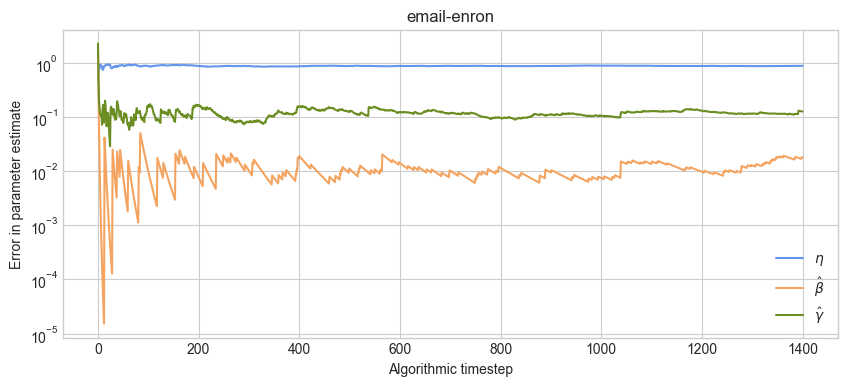

In [15]:
fig, axes = plt.subplots(1, 1, figsize = (10, 4), sharey= True)

data_name = "email-enron"
H0 = xgi.load_xgi_data(data_name)
g_len = xgi.max_edge_order(H0)
H0 = m.GrowingHypergraph(H0)
_,_,_ = experiment_KL_CS_graph(H0, data_name, g_len, 100000, 3, 4, ax = axes, batch_size = 10, verbose = False)


In [8]:
eta_1 = 0.3
eta_2 = 0.7


p_beta_1 = np.random.poisson(lam=2.0, size=10)
p_beta_1 = [x+1 for x in p_beta_1]
msum = sum(p_beta_1)
p_beta_1 = [x/msum for x in p_beta_1]
p_beta_2 = np.random.poisson(lam=3.0, size=10)
p_beta_2 = [x+1 for x in p_beta_2]
msum = sum(p_beta_2)
p_beta_2 = [x/msum for x in p_beta_2]

p_gamma_1 = np.random.poisson(lam=3.0, size=10)
p_gamma_1 = [x+1 for x in p_gamma_1]
msum = sum(p_gamma_1)
p_gamma_1 = [x/msum for x in p_gamma_1]
p_gamma_2 = np.random.poisson(lam=2.0, size=10)
p_gamma_2 = [x+1 for x in p_gamma_2]
msum = sum(p_gamma_2)
p_gamma_2 = [x/msum for x in p_gamma_2]

This hypergraph has 10002 edges and 42367 nodes.
This hypergraph has 10002 edges and 43986 nodes.


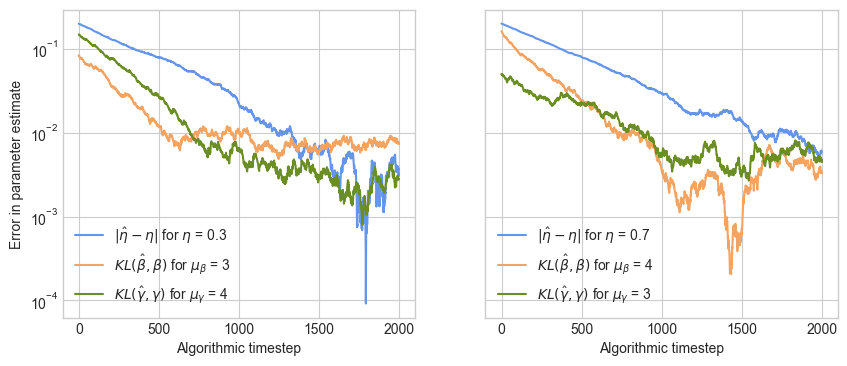

In [7]:
### Calculate Synthetic Network Properties ###

fig, axes = plt.subplots(1, 2, figsize = (10, 4), sharey= True)
axes = axes.flatten()


PARS = { "eta": eta_1,
        "beta": p_beta_1,
       "gamma": p_gamma_1}

experiment_KL(PARS, 2000, 3, 4, ax = axes[0], batch_size = 1, verbose = False)

PARS = { "eta": eta_2,
        "beta": p_beta_2,
       "gamma": p_gamma_2}

experiment_KL(PARS, 2000, 4, 3, ax = axes[1], batch_size = 1, verbose = False, legend_on = False)

plt.savefig("figures/backup_accuracy_poisson.pdf",bbox_inches='tight')

This hypergraph has 10002 edges and 50154 nodes.


C:\Users\hexie\AppData\Local\Temp\ipykernel_21236\3784986791.py:35: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.where(a != 0, a * np.log(a / b), 0))
C:\Users\hexie\AppData\Local\Temp\ipykernel_21236\3784986791.py:35: RuntimeWarning: invalid value encountered in multiply
  return np.sum(np.where(a != 0, a * np.log(a / b), 0))


--------
calculating last averaged differences
0.9969805291308919
--------
calculating last averaged differences
0.0016272493869183531
--------
calculating last averaged differences
0.00016891836082575333
Converged after  1600 steps
This hypergraph has 10002 edges and 45692 nodes.
--------
calculating last averaged differences
0.9930311866486015
--------
calculating last averaged differences
0.00040967780857163424
Converged after  1400 steps


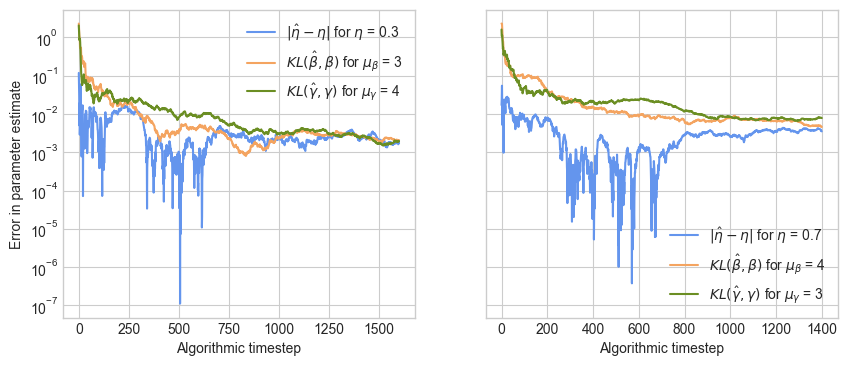

In [15]:
### Calculate Synthetic Network Properties ###

fig, axes = plt.subplots(1, 2, figsize = (10, 4), sharey= True)
axes = axes.flatten()


PARS = { "eta": eta_1,
        "beta": 
        p_beta_1,
       "gamma": p_gamma_1}

experiment_KL_CS(PARS, 10000, 3, 4, ax = axes[0], batch_size = 1, verbose = False)

PARS = { "eta": eta_2,
        "beta": p_beta_2,
       "gamma": p_gamma_2}

experiment_KL_CS(PARS, 10000, 4, 3, ax = axes[1], batch_size = 1, verbose = False, legend_on = False)

plt.savefig("figures/Accuracy_Changing_Stepsize.pdf",bbox_inches='tight')

This hypergraph has 10002 edges and 40944 nodes.
This hypergraph has 10002 edges and 50258 nodes.


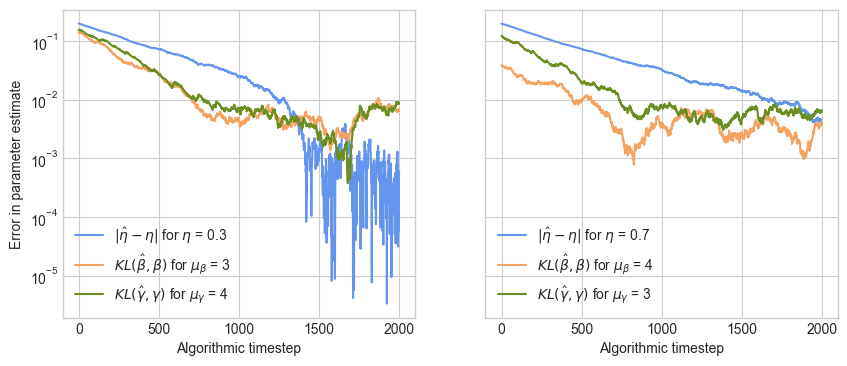

In [14]:
fig, axes = plt.subplots(1, 2, figsize = (10, 4), sharey= True)
axes = axes.flatten()

PARS = { "eta": eta_1,
        "beta": p_beta_1,
       "gamma": p_gamma_1}

experiment_KL(PARS, 2000, 3, 4, ax = axes[0], batch_size = 1, verbose = False)

PARS = { "eta": eta_2,
        "beta": p_beta_2,
       "gamma": p_gamma_2}

experiment_KL(PARS, 2000, 4, 3, ax = axes[1], batch_size = 1, verbose = False, legend_on = False)

plt.savefig("figures/Accuracy_NOADF.pdf",bbox_inches='tight')

This hypergraph has 10002 edges and 1733 nodes.
This hypergraph has 10002 edges and 12862 nodes.


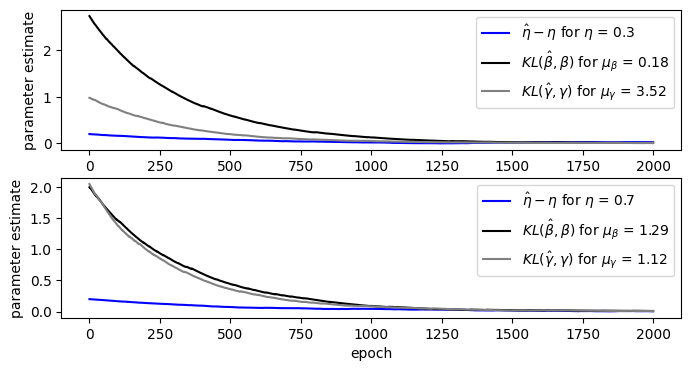

In [19]:
eta_list = [0.3, 0.7]
beta_list = []

gamma_list = []


p_beta_1 = [0.90502832570338695,
 0.06852597102421798,
 0.00695958124156278,
 0.00425430441260074,
 0.00513923414596366,
 0.00283459294063147,
 0.00219491091589968,
 0.00355751868523734,
 0.000874040537457661,
 0.0006315203930418162]

p_beta_2 = [0.1181696191800098,
 0.56904908541005407,
 0.28176865827877373,
 0.00922959431020997,
 0.0054277044922998,
 0.00429578036753658,
 0.003301470269982085,
 0.003939276201320242,
 0.00377219213273467,
 0.001046619357079092]


beta_list = [p_beta_1, p_beta_2]

#p_gamma = -np.sort(-np.random.exponential(scale=1.0, size=20))
#p_gamma = list(p_gamma / p_gamma.sum())
p_gamma_1 = [0.26808510691453546,
0.14626545184476625,
 0.10855257597549402,
 0.09914093069058083,
 0.07015466087950174,
 0.05779366818337918,
 0.040675224620690405,
 0.040422307282760035,
 0.03890813877620562,
 0.03606039013263103,
 0.026425470730908805,
 0.02167258582451556,
 0.015359102952971269,
 0.009505581418620465,
 0.0074926102365517385,
 0.00499058812177074,
 0.004907000319279024,
 0.0023934645186247435,
 0.0010124215022168882,
 0.00018271907399612376]

p_gamma_2 = [0.82894182078922285,
 0.06215493012449843,
 0.01192666284335375,
 0.00279141892191949,
 0.00847290102333172,
 0.00886377827593374,
 0.00625207194824165,
 0.00984957246975516,
 0.00301749402598405,
 0.000088960379657,
 0.00366484857364415,
 0.002608868022124676,
 0.009726750682067864,
 0.007883420960180417,
 0.008534809253028417,
 0.008444923410680536,
 0.007057473316011906,
 0.004988774770066662,
 0.003532987383654084,
 0.0011975328266434495]

gamma_list = [p_gamma_1, p_gamma_2]




The estimates, though noisy, agree well with the true values. 

# Role of Batching

In several previous experiments, we found that stochastic EM had the tendency to underestimate $\eta$ when both $\beta$ and $\gamma$ were small. The specific variant of stochastic EM in which we observed this was batch-size 1: the vector of expected sufficient statistics is formed by sampling a single edge and examining its candidate predecessors. 

However, it seems that the bias largely vanishes if we do some batching. Here's an illustration. On the lefthand plot we have the biased behavior, while on the righthand plot we recover roughly the correct value of $\eta$. Both experiments involve the same number of edge neighborhood queries. 

In [6]:
# generate some sample data

eta   = 0.6   # node retention in edges
beta  = 0.3   # poisson number of novel nodes
gamma = 0.2   # poisson number of nodes from graph

timesteps = int(10000)

H = m.GrowingHypergraph()
H.add_edge((0, 1))
H.add_edge((2, 3))

for _ in range(timesteps):
    H.sample_edge(eta, gamma, beta, True)
    
print(f"This hypergraph has {len(H.edge_size_sequence())} edges and {len(H.degree_sequence())} nodes.")


This hypergraph has 10002 edges and 3010 nodes.


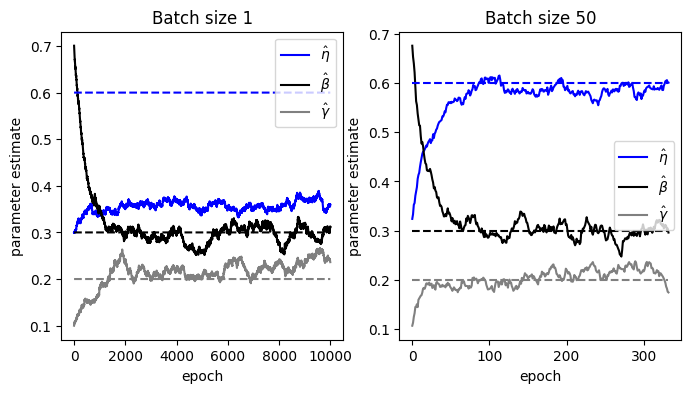

In [8]:
fig, axarr = plt.subplots(1, 2, figsize = (8, 4))
axarr[0].set(title = "Batch size 1")
axarr[1].set(title = "Batch size 50")

experiment(H, 10000, axarr[0], batch_size = 1, verbose = False)
experiment(H, 10000, axarr[1], batch_size = 30, verbose = False)

So, while the bias in the unbatched case may be important to understand, it appears that we can largely avoid it as a practical matter by batching when estimating the vector of sufficient statistics. 